In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT / "src"))

Data_dir = Path(PROJECT_ROOT/"data"/"dev_data_fan")

wav_files = list(Data_dir.rglob("*.wav"))
print(f"Number of WAV files: {len(wav_files)}")

def parse_filename(path):
    name = path.stem
    parts = name.split("_")

    return {
        "file": str(path),
        "filename": path.name,
        "section": parts[1],
        "domain": parts[2],
        "split": parts[3],
        "label": parts[4]
    }

records = [parse_filename(path) for path in wav_files]
df = pd.DataFrame(records)
df.head()

Number of WAV files: 4209


,file,filename,section,domain,split,label
0,/Applications/FAU/Application/Akustische_indus...,section_00_source_train_normal_0926_strength_1...,00,source,train,normal
1,/Applications/FAU/Application/Akustische_indus...,section_00_source_train_normal_0855_strength_1...,00,source,train,normal
2,/Applications/FAU/Application/Akustische_indus...,section_01_source_train_normal_0601_strenght_1...,01,source,train,normal
3,/Applications/FAU/Application/Akustische_indus...,section_02_source_train_normal_0577_strenght_1...,02,source,train,normal
4,/Applications/FAU/Application/Akustische_indus...,section_02_source_train_normal_0404_strenght_1...,02,source,train,normal


In [8]:
def get_sample(
        df,
        section,
        domain,
        split,
        label,
        random_state=123
):
    subset = df[
        (df["section"] == section) &
        (df["domain"] == domain) &
        (df["split"] == split) &
        (df["label"] == label)
        ]

    if len(subset) == 0:
        raise ValueError("No matching audio found.")

    return subset.sample(n=1,random_state=random_state).iloc[0]

samples = {
    "Source Normal": get_sample(
        df,
        section="00",
        domain="source",
        split="test",
        label="normal",
        random_state=123
    ),
    "Source Anomaly": get_sample(
        df,
        section="00",
        domain="source",
        split="test",
        label="anomaly",
        random_state=123
    ),
    "Target Normal": get_sample(
        df,
        section="00",
        domain="target",
        split="test",
        label="normal",
        random_state=123
    ),
    "Target Anomaly": get_sample(
        df,
        section="00",
        domain="target",
        split="test",
        label="anomaly",
        random_state=123
    )
}

for name, sample in samples.items():
    print(f"{name}:")
    print(sample["filename"])
    print()



Source Normal:
section_00_source_test_normal_0088.wav

Source Anomaly:
section_00_source_test_anomaly_0073.wav

Target Normal:
section_00_target_test_normal_0098.wav

Target Anomaly:
section_00_target_test_anomaly_0058.wav

Sampling rate: 16000 Hz
Number of samples: 160000
Duration: 10.00 seconds


Sampling rate: 16000 Hz
Number of samples: 160000
Duration: 10.00 seconds


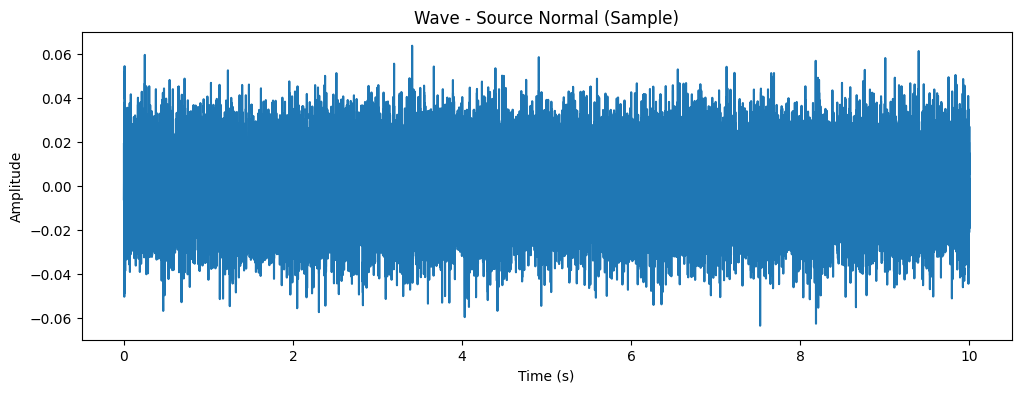

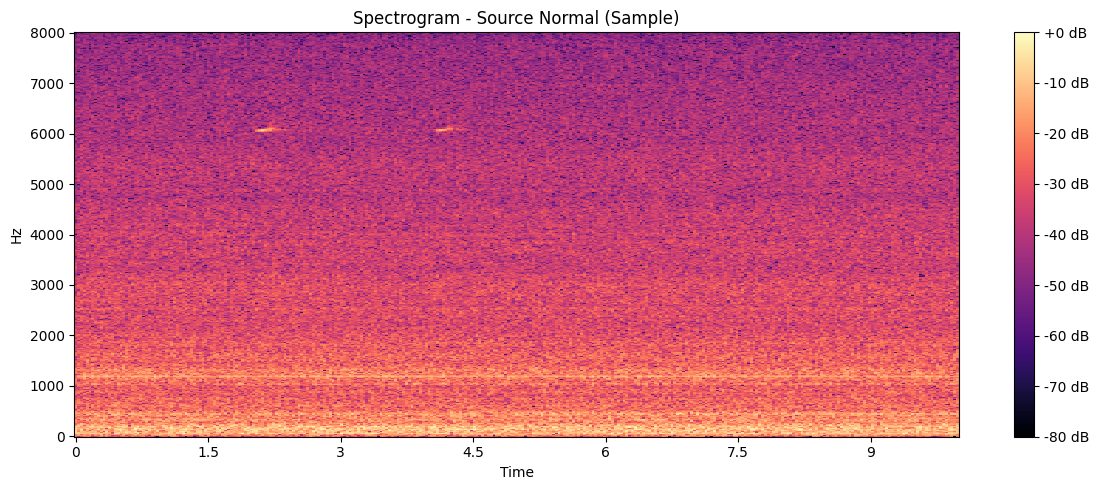

In [13]:
sample_path = samples["Source Normal"]["file"]

y, sr = librosa.load(
    sample_path,
    sr=None,
    mono=True
)

print(f"Sampling rate: {sr} Hz")
print(f"Number of samples: {len(y)}")
print(f"Duration: {len(y)/sr:.2f} seconds")

time = np.arange(len(y)) / sr

plt.figure(figsize=(12,4))
plt.plot(time, y)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Wave - Source Normal (Sample)")

plt.tight_layout
plt.show()

D = librosa.stft(
    y,
    n_fft=1024,
    hop_length=512
)

S_db = librosa.amplitude_to_db(
    np.abs(D),
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram - Source Normal (Sample)")

plt.tight_layout()
plt.show()

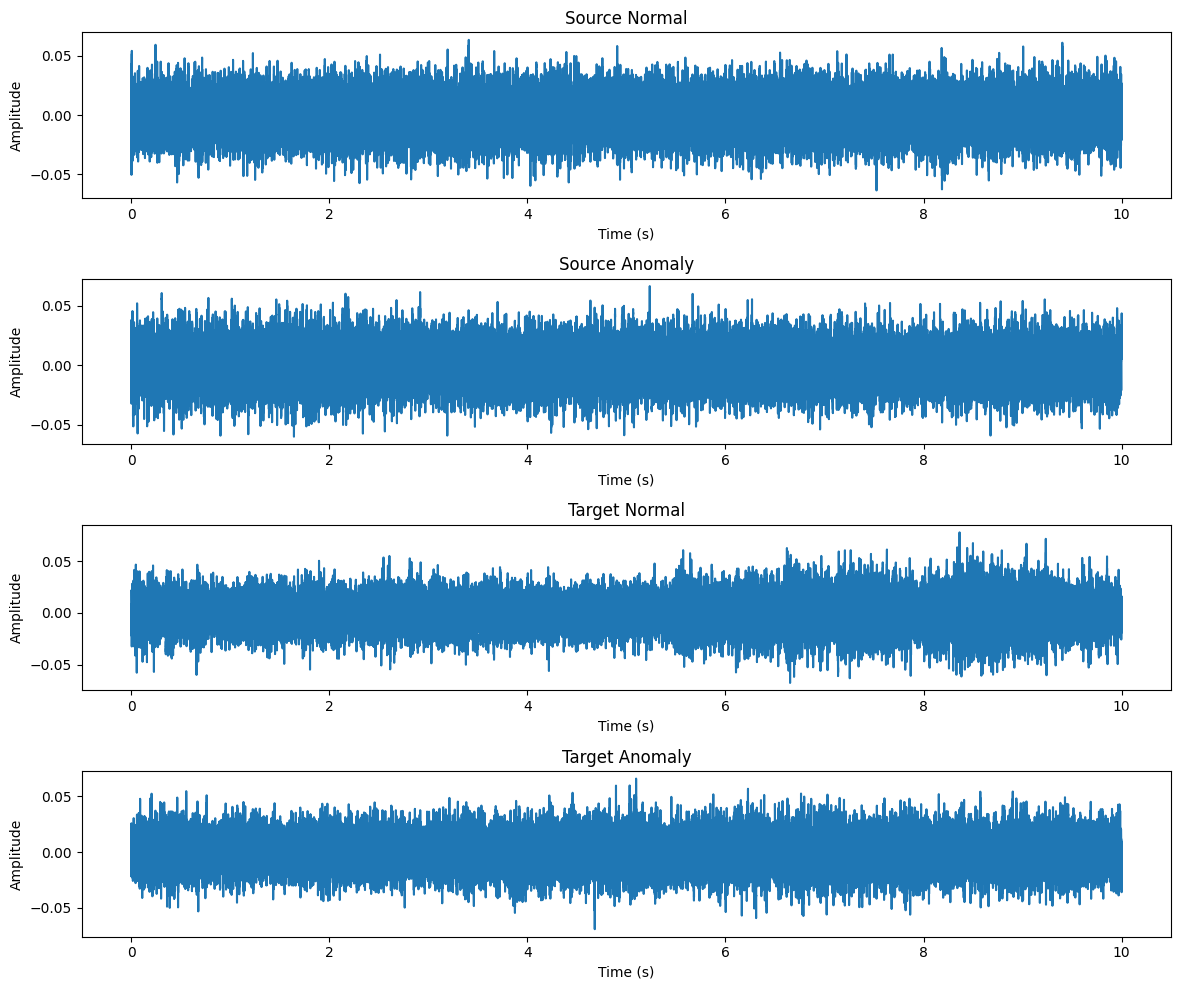

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12,10))

for ax, (name, sample) in zip(axes, samples.items()):
    y, sr = librosa.load(
        sample["file"],
        sr=None,
        mono=True
    )

    time = np.arange(len(y)) / sr

    ax.plot(time, y)

    ax.set_title(name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


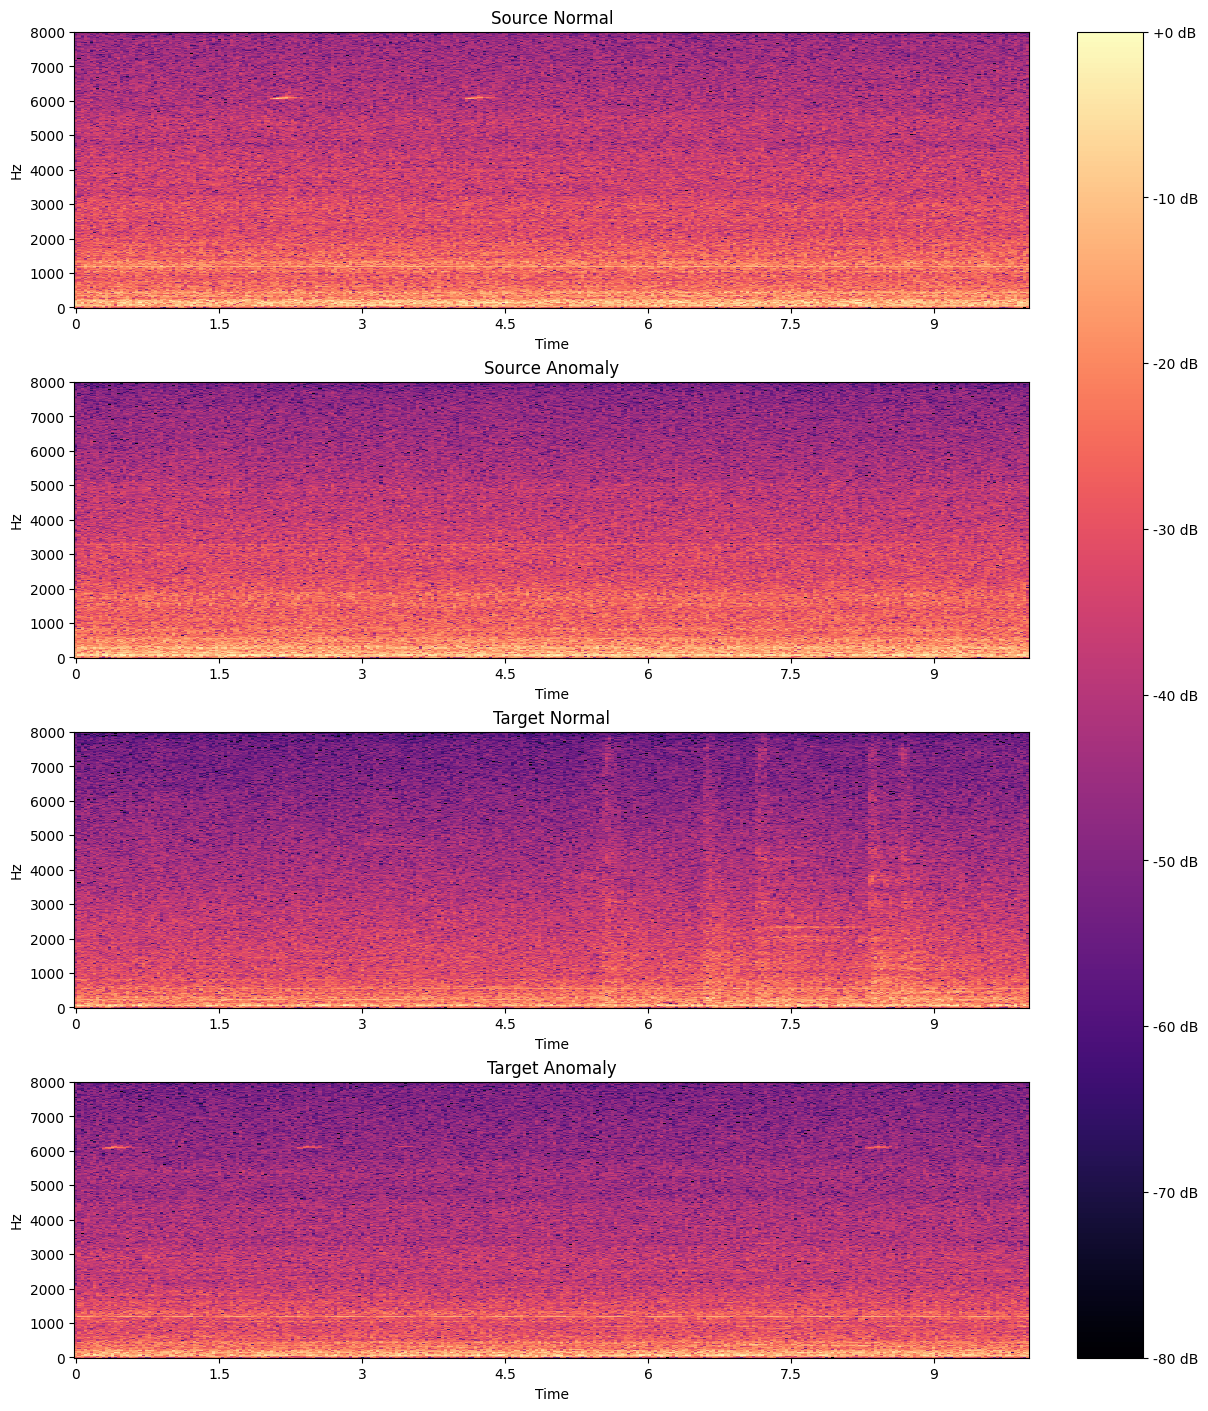

In [16]:
def plot_spectrogram(ax, y, sr, title):
    D = librosa.stft(
        y,
        n_fft=1024,
        hop_length=512
    )

    S_db = librosa.amplitude_to_db(
        np.abs(D),
        ref=np.max
    )

    img = librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=512,
        x_axis="time",
        y_axis="hz",
        ax=ax,
        vmin=-80,
        vmax=0
    )

    ax.set_title(title)

    return img

fig, axes = plt.subplots(4,1,figsize=(12,14),constrained_layout=True)

for ax, (name, sample) in zip (axes, samples.items()):
    y, sr = librosa.load(
        sample["file"],
        sr=None,
        mono=True
    )

    img = plot_spectrogram(ax, y, sr, name)

fig.colorbar(
    img,
    ax=axes,
    location="right",
    format="%+2.0f dB"
)

#plt.tight_layout()
plt.show()